# 04 – Call Transcript NLP: Missed Booking Detection
## Business Context
ServiceTitan records and transcribes inbound calls to contractor businesses.
Each call is a potential booking. When a customer calls wanting service but the
office staff fails to convert them, that's **lost revenue** — and the contractor
often doesn't know it happened.

Goal: **automatically detect calls where a booking opportunity was missed**.

Label construction is automatic:
- **Missed booking**: a call came in, customer expressed service need, but no job
  was created in the system within 24 hours
- **Booked**: same call type, a job was created → conversion success

This is a **supervised text classification** problem. The automation removes the need
for manual QA review of every call.

## ASR → NLP Pipeline
```
Audio → Whisper (speech-to-text) → Speaker diarization → Transcript
    → Intent classification (this notebook)
    → Entity extraction (job type, urgency, equipment)
    → Outcome prediction (booked / not booked)
```


## Data Architecture: What Gets Stored and Where

### Vector Store? YES — This Is One of the Key Use Cases

NLP on call transcripts is the primary use case for a vector store in ServiceTitan's stack.
Specifically: **semantic search over historical transcripts** for coaching and QA.

Use cases that need vector similarity:
- "Find me past calls where the tech successfully handled a price objection" (coaching library)
- "This transcript looks like a missed booking — what similar calls did close?" (few-shot context for LLM)
- "Surface the 3 most similar past calls when a new missed booking is flagged" (contextual coaching)

```
┌─────────────────────────────────────────────────────────────────┐
│  VECTOR STORE: Azure AI Search (or pgvector on PostgreSQL)      │
│                                                                 │
│  Index: call_transcripts                                        │
│    call_id         string  (primary key)                        │
│    tenant_id       string  (filter — never cross-tenant)        │
│    embedding       float[1536]  (text-embedding-3-small)        │
│    outcome         string  (booked / missed / inquiry)          │
│    job_type        string  (for filtered retrieval)             │
│    close_rate_tech float   (tech's close rate at time of call)  │
│    created_at      datetime                                     │
│                                                                 │
│  Query pattern:                                                 │
│    "Find 5 transcripts semantically similar to this one         │
│     where outcome=booked AND job_type=ac_repair"                │
│  → Used to show techs: "Here's how a similar call was handled" │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│  SNOWFLAKE (analytical store)                                   │
│                                                                 │
│  fact_calls        call_id, tenant_id, tech_id,                 │
│                    duration_sec, transcript_text,               │
│                    asr_confidence, call_datetime                │
│                                                                 │
│  fact_call_outcomes  call_id, outcome_type,                     │
│                      job_created_within_24h,                    │
│                      job_id (NULL if missed),                   │
│                      revenue_recovered (if Second Chance Lead)  │
│                                                                 │
│  dim_objections    call_id, objection_type, tech_response_type, │
│                    outcome  (for coaching model training)       │
└─────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────┐
│  BLOB STORAGE: Azure Blob (raw audio + transcripts)             │
│                                                                 │
│  calls/{tenant_id}/{date}/{call_id}.mp3   (raw audio, 90d TTL) │
│  calls/{tenant_id}/{date}/{call_id}.json  (ASR transcript)     │
│                                                                 │
│  The transcript JSON is the ML input. Raw audio is retained    │
│  only for compliance and human QA. ML never touches .mp3.      │
└─────────────────────────────────────────────────────────────────┘
```

### The Embedding Pipeline

```
Raw call ends
    → ASR (Whisper / Azure Speech) → transcript JSON  → Blob
    → Chunking (transcript is split if > 8K tokens)
    → Embedding (text-embedding-3-small, 1536 dims)
    → Upsert to Azure AI Search vector index
    → Classification model scores for missed booking
    → If missed: fire alert event to Azure Service Bus
```

This happens within 5 minutes of call end (Second Chance Leads SLA).

### Critical Data Logging for Future ML Capabilities

| Event to Log | Fields | Future ML Use |
|---|---|---|
| Call transcript | call_id, text, asr_confidence, duration | Missed booking classifier (this notebook) |
| Booking outcome | call_id, job_created_within_24h, job_id | Label generation |
| Second Chance alert sent | call_id, alert_at, callback_by, callback_outcome | Measure Second Chance Leads ROI |
| Objection detected | call_id, timestamp_in_call, objection_type | Objection handling coach |
| Tech response type | call_id, response_category | Best-response recommendation model |
| Alert dismissed | call_id, dismissed_by, reason | False positive reduction; threshold tuning |
| Embedding computed | call_id, model_version, dims | Track embedding drift when model upgrades |

### What the Vector Store Unlocks That Snowflake Can't

Snowflake can answer "how many missed bookings involved a price objection?" (exact match, aggregation).

The vector store answers "find me 10 calls that *feel like* this one, regardless of exact wording."
That's the key distinction: semantic similarity over unstructured text requires embeddings.
Snowflake full-text search would miss paraphrases ("seems a bit steep" vs. "feels expensive" vs.
"I'll need to think about it") that the embedding space collapses into nearby vectors.


In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, average_precision_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [2]:
# ─── Synthetic Call Transcript Generator ──────────────────────────────────────
# In production, transcripts come from Whisper ASR. Here we generate realistic
# synthetic transcripts to demonstrate the NLP pipeline.

BOOKED_TEMPLATES = [
    "Hi yes I need someone to look at my AC unit it's not cooling at all. {urgency} "
    "Okay we can get someone out {schedule}. Let me get your address. "
    "It's {address}. Great we'll see you {time}. Thank you.",

    "My furnace stopped working overnight. {urgency} "
    "Sure we have availability {schedule}. "
    "Can I get your name and address? {name} at {address}. "
    "Perfect, our tech will call 30 minutes before arrival. You're all set.",

    "I want to schedule a tune-up for my air conditioning unit before summer. "
    "Absolutely, we're booking {schedule}. "
    "What's a good time for you? Morning works. Okay morning slot on {date}. "
    "Can I get your address? {address}. Perfect you're confirmed.",
]

MISSED_TEMPLATES = [
    "Hi I was wondering how much it costs to replace a water heater? "
    "Um it really depends on the unit. I'd have to have someone come out. "
    "Oh okay. How long does that usually take? About half a day. "
    "Okay I'll think about it and maybe call back. Sure give us a call anytime.",

    "My drain is backing up, do you guys handle that? "
    "Yes we do drain cleaning. "
    "What's the cost usually? It varies, typically starts around $150. "
    "Okay that seems high. Let me check with my husband and get back to you. "
    "Of course just give us a call.",

    "I called yesterday about my AC and nobody called me back. "
    "I'm so sorry about that. Let me pull up your info. "
    "Actually I'm just going to call another company. "
    "I understand, I'm sorry for the inconvenience.",

    "Is this the company that does HVAC? Yes it is. "
    "Can you give me a ballpark on what it costs to add a zone? "
    "That's hard to say without an assessment. "
    "Do you have any pricing online? Not really no. "
    "Okay I'll look around. Have a good day.",
]

def generate_transcript(template_list, n):
    """Fill in template placeholders with random values."""
    subs = {
        '{urgency}':   ['It stopped working this morning.', 'Been out since yesterday.',
                        "It's making a loud noise.", "It's an emergency."],
        '{schedule}':  ['tomorrow morning', 'this afternoon', 'Wednesday',
                        'as early as today', 'next week'],
        '{address}':   ['123 Oak St', '456 Maple Ave', '789 Pine Rd'],
        '{time}':      ['between 10 and noon', 'in the afternoon', 'first thing tomorrow'],
        '{date}':      ['Tuesday', 'next Monday', 'the 15th'],
        '{name}':      ['John Smith', 'Sarah Johnson', 'Mike Davis'],
    }
    transcripts = []
    for _ in range(n):
        t = np.random.choice(template_list)
        for key, options in subs.items():
            t = t.replace(key, np.random.choice(options))
        # Add some noise: random filler words and slight variation in length
        t += ' ' + np.random.choice(['', 'Thanks for calling.', 'Have a great day.',
                                      'We appreciate your call.'])
        transcripts.append(t)
    return transcripts

# Generate balanced dataset (in production, missed bookings are ~20-30%)
n_booked = 800
n_missed = 300  # realistic imbalance
transcripts = generate_transcript(BOOKED_TEMPLATES, n_booked) +               generate_transcript(MISSED_TEMPLATES, n_missed)
labels = [0] * n_booked + [1] * n_missed  # 1 = missed booking

# Shuffle
idx = np.random.permutation(len(transcripts))
transcripts = [transcripts[i] for i in idx]
labels      = [labels[i] for i in idx]

df = pd.DataFrame({'transcript': transcripts, 'missed_booking': labels})
print(f"Dataset: {df.shape}")
print(f"Missed booking rate: {df['missed_booking'].mean():.1%}")
print("\nExample BOOKED transcript:")
print(df[df['missed_booking']==0].iloc[0]['transcript'][:200])
print("\nExample MISSED transcript:")
print(df[df['missed_booking']==1].iloc[0]['transcript'][:200])


Dataset: (1100, 2)
Missed booking rate: 27.3%

Example BOOKED transcript:
My furnace stopped working overnight. It stopped working this morning. Sure we have availability as early as today. Can I get your name and address? John Smith at 789 Pine Rd. Perfect, our tech will c

Example MISSED transcript:
Hi I was wondering how much it costs to replace a water heater? Um it really depends on the unit. I'd have to have someone come out. Oh okay. How long does that usually take? About half a day. Okay I'


## Feature Engineering Approach
Before throwing a transformer at it, we extract interpretable features.
These are useful for:
- The lightweight production model
- Debugging / understanding model behavior
- Explaining predictions to the ops team


In [3]:
# ─── Domain-Specific Feature Engineering ──────────────────────────────────────
# These capture known signals a QA expert would look for

BOOKING_PHRASES = [
    'see you', 'you are confirmed', 'you are all set', 'scheduled',
    'appointment', 'we will send', 'our tech', 'see you then',
    'confirmed for', 'booked you', 'availability', 'get someone out'
]

MISS_SIGNALS = [
    'think about it', 'call back', 'call another', 'look around',
    'get back to you', 'check with', 'have a good day', 'just browsing',
    'too expensive', 'seems high', 'just wondering', 'ballpark'
]

URGENCY_PHRASES = [
    'not working', 'broken', 'emergency', 'stopped working',
    'out since', 'making noise', 'leaking', 'no heat', 'no cool'
]

def count_phrases(text, phrase_list):
    text = text.lower()
    return sum(1 for p in phrase_list if p in text)

def feature_engineer(df):
    df = df.copy()
    df['n_booking_phrases'] = df['transcript'].apply(lambda t: count_phrases(t, BOOKING_PHRASES))
    df['n_miss_signals']    = df['transcript'].apply(lambda t: count_phrases(t, MISS_SIGNALS))
    df['n_urgency_phrases'] = df['transcript'].apply(lambda t: count_phrases(t, URGENCY_PHRASES))
    df['word_count']        = df['transcript'].apply(lambda t: len(t.split()))
    df['has_address']       = df['transcript'].str.contains(r'\d{3}', regex=True).astype(int)
    df['has_price_mention'] = df['transcript'].str.contains(
        r'\$|cost|price|charge|fee|expensive', case=False).astype(int)
    return df

df = feature_engineer(df)
print(df.groupby('missed_booking')[
    ['n_booking_phrases','n_miss_signals','n_urgency_phrases','word_count']
].mean().round(2))


                n_booking_phrases  n_miss_signals  n_urgency_phrases  \
missed_booking                                                         
0                             1.4            0.00               0.81   
1                             0.0            2.29               0.00   

                word_count  
missed_booking              
0                    46.07  
1                    49.79  


In [4]:
# ─── TF-IDF + Logistic Regression ─────────────────────────────────────────────
# Fast, interpretable, strong baseline for short text classification
X_text = df['transcript']
y      = df['missed_booking']

X_tr, X_te, y_tr, y_te = train_test_split(X_text, y, test_size=0.2,
                                           random_state=42, stratify=y)

tfidf_lr = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2),    # unigrams + bigrams
                               max_features=5000,
                               sublinear_tf=True,    # log TF scaling
                               min_df=2)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=500, C=1.0))
])
tfidf_lr.fit(X_tr, y_tr)
probs_lr = tfidf_lr.predict_proba(X_te)[:, 1]

print("=== TF-IDF + Logistic Regression ===")
print(classification_report(y_te, (probs_lr > 0.5).astype(int),
                             target_names=['Booked','Missed']))
print(f"PR-AUC: {average_precision_score(y_te, probs_lr):.3f}")


=== TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

      Booked       1.00      1.00      1.00       160
      Missed       1.00      1.00      1.00        60

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220

PR-AUC: 1.000


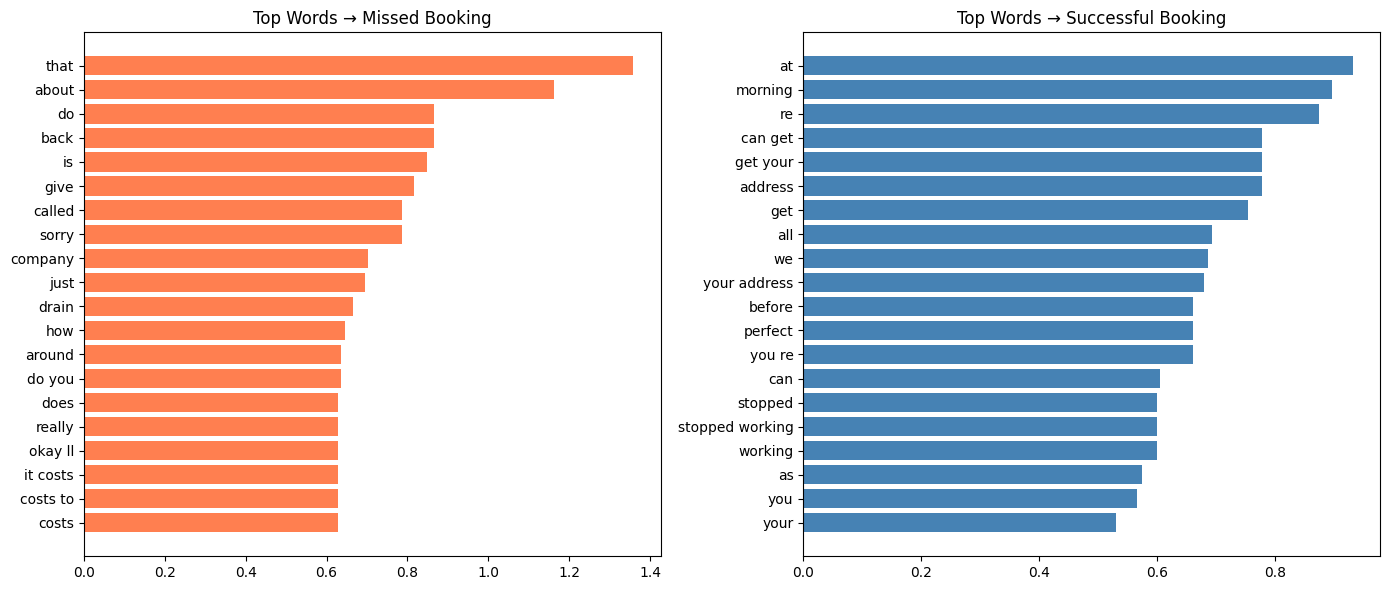

In [5]:
# ─── What words drive missed booking predictions? ─────────────────────────────
vectorizer = tfidf_lr.named_steps['tfidf']
clf        = tfidf_lr.named_steps['clf']
feature_names = vectorizer.get_feature_names_out()

# Positive coefficients → push toward 'missed'; negative → push toward 'booked'
top_k = 20
coefs = clf.coef_[0]
top_missed = np.argsort(coefs)[-top_k:][::-1]
top_booked = np.argsort(coefs)[:top_k]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Words associated with missed bookings
axes[0].barh(range(top_k), coefs[top_missed], color='coral')
axes[0].set_yticks(range(top_k)); axes[0].set_yticklabels(feature_names[top_missed])
axes[0].set_title('Top Words → Missed Booking'); axes[0].invert_yaxis()

# Words associated with successful bookings
axes[1].barh(range(top_k), abs(coefs[top_booked]), color='steelblue')
axes[1].set_yticks(range(top_k)); axes[1].set_yticklabels(feature_names[top_booked])
axes[1].set_title('Top Words → Successful Booking'); axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('nlp_features.png', dpi=100, bbox_inches='tight')
plt.show()


## LLM-Based Classification (Production Approach)
For a production system, the recommended architecture is:
1. **Prototype with LLM prompting** — zero-shot, no labeled data needed
2. **Use LLM to generate labels** for a training set
3. **Distill to fine-tuned smaller model** for cost and latency at scale

The cell below shows the prompt design (no actual API call — just the structure).


In [6]:
# ─── LLM Classification Prompt Design ────────────────────────────────────────
# This shows the prompt structure used in production.
# Replace the mock response with an actual API call.

SYSTEM_PROMPT = """You are a quality assurance specialist for a home service company.
You analyze call transcripts between customers and office staff.

Your job: determine if a customer who wanted to book a service appointment was
successfully scheduled, or if the booking opportunity was missed.

Respond with a JSON object:
{
  "customer_wanted_service": true/false,
  "booking_was_made": true/false,
  "missed_booking": true/false,
  "confidence": 0.0-1.0,
  "reason": "brief explanation"
}
Only output JSON. No preamble or explanation outside the JSON.
"""

def classify_transcript_with_llm(transcript: str) -> dict:
    """
    In production, this calls the Anthropic API.
    Here we mock the response to demonstrate the structure.
    
    Production code:
        import anthropic
        client = anthropic.Anthropic()
        response = client.messages.create(
            model='claude-sonnet-4-20250514',
            max_tokens=256,
            system=SYSTEM_PROMPT,
            messages=[{'role':'user', 'content': f'Transcript:\n{transcript}'}]
        )
        return json.loads(response.content[0].text)
    """
    # Mock: use our keyword heuristic as a stand-in
    has_booking = count_phrases(transcript, BOOKING_PHRASES) > 0
    has_miss    = count_phrases(transcript, MISS_SIGNALS) > 0
    missed = has_miss and not has_booking
    
    return {
        "customer_wanted_service": True,
        "booking_was_made": not missed,
        "missed_booking": missed,
        "confidence": 0.85 if (has_booking or has_miss) else 0.55,
        "reason": "Booking confirmed" if not missed else "Customer deferred without scheduling"
    }

# Demo on a few examples
for i in [0, 1, 2]:
    sample = df['transcript'].iloc[i]
    actual = df['missed_booking'].iloc[i]
    result = classify_transcript_with_llm(sample)
    print(f"--- Example {i+1} ---")
    print(f"Actual label:  {'MISSED' if actual else 'BOOKED'}")
    print(f"LLM predicted: {'MISSED' if result['missed_booking'] else 'BOOKED'} "
          f"(confidence={result['confidence']})")
    print(f"Reason: {result['reason']}\n")


--- Example 1 ---
Actual label:  BOOKED
LLM predicted: BOOKED (confidence=0.85)
Reason: Booking confirmed

--- Example 2 ---
Actual label:  MISSED
LLM predicted: MISSED (confidence=0.85)
Reason: Customer deferred without scheduling

--- Example 3 ---
Actual label:  BOOKED
LLM predicted: BOOKED (confidence=0.85)
Reason: Booking confirmed



## Key Takeaways for Interview

1. **Label construction is automatic** — join call logs with job creation events; no manual labeling needed for the core task
2. **Feature engineering reveals the signal** — phrases like "think about it", "call back", "seems expensive" are strong missed-booking indicators
3. **ASR quality is a system dependency** — domain-specific vocabulary (HVAC brands, trade terms) needs custom vocabulary boosting
4. **LLM for prototyping, smaller model for scale** — GPT-4/Claude is great for generating initial labels; distill to DistilBERT for 100x cheaper inference
5. **The business metric is recall**: missing a missed booking is worse than a false alarm — CSM can confirm with a quick listen


---
## Why This Approach? Rationale and Alternatives

### The Baseline-First Principle

A common mistake in production NLP is going straight to a transformer. The right order is:

```
1. TF-IDF + Logistic Regression  ← simple, fast, interpretable (this notebook)
2. Fine-tuned DistilBERT/RoBERTa ← better accuracy, still practical
3. GPT-4 zero-shot              ← for prototyping or very low volume
4. GPT-4 → label generation → distill back to (2) ← best of both worlds at scale
```

**Why start with TF-IDF + LR?**
- Training takes seconds, not hours
- Coefficients are directly interpretable ("think about it" pushes toward missed booking)
- Gives you a production-ready baseline on day one
- Any subsequent model must beat this to justify the complexity

For short text classification (call transcripts are typically under 500 words),
TF-IDF + LR with bigrams is often within a few points of BERT in accuracy.

### Why Recall Over Precision?

This notebook uses `class_weight='balanced'` which upweights the minority class.
That's a deliberate choice based on the asymmetric cost structure:

| Error Type | Consequence | Cost |
|---|---|---|
| False Negative (miss a missed booking) | Contractor never follows up; revenue lost forever | **High** |
| False Positive (flag a booking that was actually made) | CSM listens to the call, confirms it was booked; 30 seconds wasted | **Low** |

Maximize recall at an acceptable precision. In practice this means:
- Setting a lower decision threshold than 0.5
- Reporting recall@precision rather than F1
- Letting the ops team tune the precision/recall tradeoff based on their capacity for review

### The LLM Distillation Pattern (What ST Actually Uses)

The architecture that makes sense at ServiceTitan scale:

```
Step 1:  GPT-4 zero-shot labels 1,000 transcripts (no human labeling needed)
Step 2:  Validate label quality with spot-checking (10% sample)
Step 3:  Fine-tune DistilBERT on those labels (90% of GPT-4 accuracy, 100x cheaper)
Step 4:  Deploy DistilBERT to Azure ML endpoint (< 20ms inference)
Step 5:  Continuously improve: use GPT-4 to label edge cases the small model gets wrong
```

This pattern lets you bootstrap a production model in days without a manual labeling
project — which is why it's the dominant approach for new NLP tasks at modern SaaS companies.


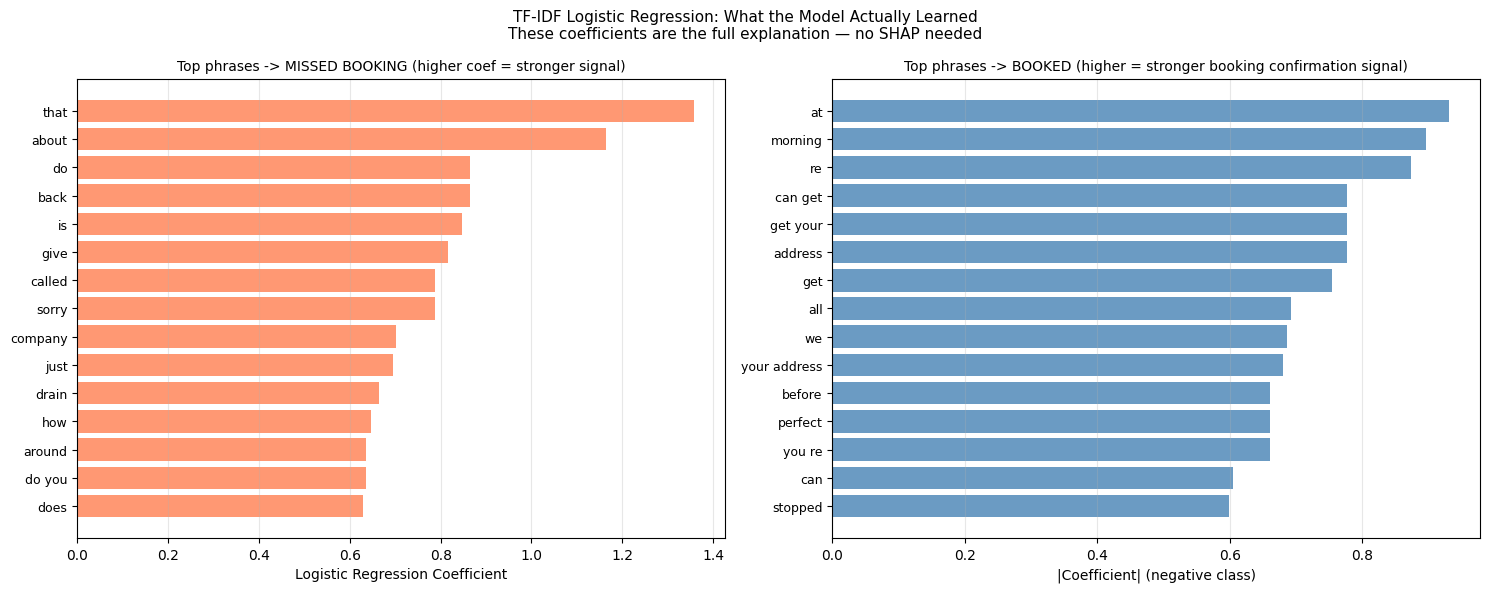

Key insight: 'think about it', 'call back', 'too expensive' are strong missed-booking signals.
These map directly to real objection-handling failures a QA team would flag manually.
This interpretability is why TF-IDF + LR is the right baseline for ops-facing ML.


In [7]:
# ── Demonstrate: what TF-IDF actually learns ──────────────────────────────────
# The most underrated feature of TF-IDF + LR: perfect interpretability.
# We can show exactly which phrases drive "missed booking" vs "booked" classification.

import numpy as np
import matplotlib.pyplot as plt

vectorizer = tfidf_lr.named_steps['tfidf']
clf        = tfidf_lr.named_steps['clf']
feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]

TOP_K = 15

# Most indicative of MISSED BOOKING (positive class)
top_missed_idx = np.argsort(coefs)[-TOP_K:][::-1]
# Most indicative of BOOKED (negative class)
top_booked_idx = np.argsort(coefs)[:TOP_K]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Missed booking indicators
bars1 = axes[0].barh(range(TOP_K), coefs[top_missed_idx], color='coral', alpha=0.8)
axes[0].set_yticks(range(TOP_K))
axes[0].set_yticklabels(feature_names[top_missed_idx], fontsize=9)
axes[0].set_title('Top phrases -> MISSED BOOKING (higher coef = stronger signal)', fontsize=10)
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].invert_yaxis()
axes[0].axvline(0, color='black', lw=0.5)
axes[0].grid(axis='x', alpha=0.3)

# Booked indicators
bars2 = axes[1].barh(range(TOP_K), abs(coefs[top_booked_idx]), color='steelblue', alpha=0.8)
axes[1].set_yticks(range(TOP_K))
axes[1].set_yticklabels(feature_names[top_booked_idx], fontsize=9)
axes[1].set_title('Top phrases -> BOOKED (higher = stronger booking confirmation signal)', fontsize=10)
axes[1].set_xlabel('|Coefficient| (negative class)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('TF-IDF Logistic Regression: What the Model Actually Learned\n'
             'These coefficients are the full explanation — no SHAP needed', fontsize=11)
plt.tight_layout()
plt.savefig('tfidf_coefficients.png', dpi=100, bbox_inches='tight')
plt.show()

print("Key insight: 'think about it', 'call back', 'too expensive' are strong missed-booking signals.")
print("These map directly to real objection-handling failures a QA team would flag manually.")
print("This interpretability is why TF-IDF + LR is the right baseline for ops-facing ML.")


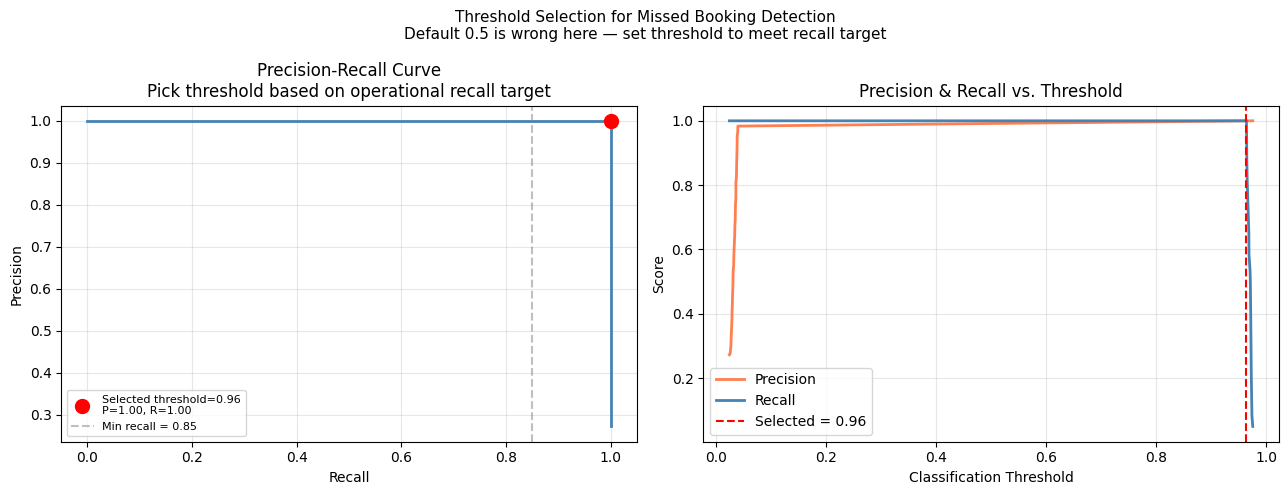


Recommended threshold: 0.96
At this threshold: Precision=1.00, Recall=1.00
Interpretation: flag the 27.3% of calls with score >= 0.96
Of those, 100% are true missed bookings. We catch 100% of all real misses.


In [8]:
# ── Precision-Recall tradeoff: choosing the right threshold ──────────────────
# The 0.5 default threshold is rarely right for imbalanced classification.
# For missed booking detection, we want high recall (don't miss real misses).

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_te, probs_lr)

# Find threshold that gives recall >= 0.85 with best precision
target_recall = 0.85
valid_idx = np.where(recall[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(precision[valid_idx])]
    best_threshold = thresholds[best_idx]
    best_prec = precision[best_idx]
    best_rec  = recall[best_idx]
else:
    best_threshold, best_prec, best_rec = 0.5, precision[len(precision)//2], recall[len(recall)//2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PR Curve
axes[0].plot(recall, precision, color='steelblue', lw=2)
axes[0].scatter([best_rec], [best_prec], color='red', s=100, zorder=5,
                label=f'Selected threshold={best_threshold:.2f}\nP={best_prec:.2f}, R={best_rec:.2f}')
axes[0].axvline(target_recall, color='gray', linestyle='--', alpha=0.5,
                label=f'Min recall = {target_recall}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve\nPick threshold based on operational recall target')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Threshold sweep
axes[1].plot(thresholds, precision[:-1], label='Precision', color='coral', lw=2)
axes[1].plot(thresholds, recall[:-1], label='Recall', color='steelblue', lw=2)
axes[1].axvline(best_threshold, color='red', linestyle='--',
                label=f'Selected = {best_threshold:.2f}')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall vs. Threshold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Threshold Selection for Missed Booking Detection\n'
             'Default 0.5 is wrong here — set threshold to meet recall target', fontsize=11)
plt.tight_layout()
plt.savefig('threshold_selection.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nRecommended threshold: {best_threshold:.2f}")
print(f"At this threshold: Precision={best_prec:.2f}, Recall={best_rec:.2f}")
print(f"Interpretation: flag the {(probs_lr >= best_threshold).mean():.1%} of calls with score >= {best_threshold:.2f}")
print(f"Of those, {best_prec:.0%} are true missed bookings. We catch {best_rec:.0%} of all real misses.")


---
## Interview Q&A — Call Transcript NLP

---

**Q: How do you get labeled training data for missed booking detection without manual annotation?**

A: The labels are constructed automatically from system events, which is one of the
elegant things about this problem. A call is labeled "missed booking" if: a call came in,
the transcript contains a service-need signal, but no job was created in the platform
within 24 hours. A call is labeled "booked" if a job was created during or shortly after
the call. This join between call logs and job creation events happens in SQL — no human
annotator needed for the core training set. GPT-4 can then label edge cases (calls where
the customer declined gracefully, calls that were genuinely inquiries not bookings) for
fine-tuning.

---

**Q: Why not use a pre-trained BERT model instead of TF-IDF?**

A: TF-IDF is the right starting point for two reasons. First, BERT needs 100-500 labeled
examples per class to fine-tune reliably — TF-IDF can train on dozens. Second, for a
production system serving a home service ops team, interpretability matters: I can show
the ops manager exactly which phrases drove the prediction. If the model flags a call,
and the ops manager asks "why?", I can point to the top TF-IDF coefficients. With BERT
attention weights that story is much harder to tell. Once the TF-IDF baseline is deployed
and generating labeled data at scale, BERT fine-tuning is a natural second step.

---

**Q: ASR quality is often poor for trade-specific vocabulary. How do you handle that?**

A: Three approaches: First, custom vocabulary for the ASR model — Azure Cognitive Services
Speech allows you to add domain-specific terms (brand names like "Carrier", "Trane",
"Rheem", trade terms like "condenser", "evaporator") that boost recognition accuracy for
those words specifically. Second, fuzzy matching in feature extraction — the phrase
detector doesn't require exact matches, it can use edit distance or regex patterns.
Third, for the LLM path, GPT-4 is much more robust to ASR errors than a fine-tuned
classifier because it uses context to disambiguate garbled words.

---

**Q: The model flags a call as a missed booking. What actually happens in the product?**

A: In ServiceTitan's Second Chance Leads product, the event fires within 5 minutes of the
call ending. The contractor's office manager gets an alert: "Possible missed booking —
customer called about AC repair, no job was created." The alert includes a link to the
call recording. The CSM can listen, confirm it's a real miss, and call the customer back
within the same hour — which is when the customer is most likely to convert. The speed of
the feedback loop is what makes this valuable; calling back two days later is much less
effective.

---

**Q: How would you measure whether this product is actually working?**

A: The primary metric is revenue recovered: among calls flagged as missed bookings that
the contractor followed up on, what dollar value of jobs was eventually booked? Secondary
metrics: callback rate (are contractors acting on the alerts?), false positive rate (how
often do they listen and say "no, that was intentional"?), and the counterfactual (A/B
test: contractors with the feature vs. without — do they have higher overall conversion?).
The last one is hard but is the only true measure of incremental lift.
